# S6 · Validating Models on Time Series: Walk-Forward and Purged Cross-Validation

*Signal Research track*

Standard machine-learning validation silently cheats on financial data. This notebook shows exactly how much, and how to validate properly.

## 1. Motivation

A student trains a gradient-boosting model on the S5 features, runs scikit-learn's standard 5-fold cross-validation, and finds an information coefficient of 0.2: four times better than anything in the professional literature. They are about to present it to the club. Then someone asks how the folds were split. The answer: randomly. As we will see, that one choice is responsible for the entire result.

## 2. Intuition

**Cross-validation** estimates how well a model will do on new data: hide part of the data, train on the rest, test on the hidden part, and repeat.

The standard version shuffles the data randomly into folds. That's fine when observations are independent, like photos of cats. Financial observations are not:

1. **Overlapping labels.** Our target is the return over the next 21 days. The labels for Monday and Tuesday share 20 of their 21 days, so they are almost the same number. If Monday is in the training set and Tuesday in the test set, the model has effectively seen the answer.
2. **Slow-moving features.** A stock's 12-month momentum barely changes from one day to the next. The model can "recognise" the test day from its neighbour in training and simply recall its label.

Together, these let a flexible model **memorise** instead of learn. The fixes all follow one principle: **test only on data that comes after a gap from everything the model was trained on.**

- **Blocked folds:** split by time, not at random.
- **Purging:** remove training observations whose label window overlaps the test period.
- **Embargo:** also drop a short buffer right after the test period, because features computed there can still contain information from it.
- **Walk-forward:** the most realistic. Train only on the past, test on the next period, roll forward. It mimics exactly what you would have done in real time.

## 3. The math

Each observation $i$ has a feature date $t_i$ and a label that depends on returns over $[t_i, t_i + h]$. Two observations **overlap** if their label windows intersect: $|t_i - t_j| < h$.

For a test fold covering dates $[a, b]$:

- **Purged training set:** keep observation $j$ only if its label window doesn't touch the test window, i.e. $t_j + h < a$ or $t_j > b$.
- **Embargo** of $e$ days: additionally drop $t_j \in (b, b + e]$.

Since the purge removes about $h$ days on each side of every fold, its cost in lost data is roughly $2h \times (\text{number of folds})$ days.

**Walk-forward** with yearly steps: for each year $Y$, train on all observations with $t_j + h <$ January 1st of year $Y$, then test on year $Y$.

**The metric.** As in S5, we evaluate with the average daily IC: the rank correlation between predictions and realised forward returns across stocks, averaged over test dates.

## 4. Code it

### 4.1 Setup: the S5 features as a panel

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
prices = pd.read_csv("../data/prices.csv", index_col="date", parse_dates=True)
volume = pd.read_csv("../data/volume.csv", index_col="date", parse_dates=True)
meta = pd.read_csv("../data/meta.csv")

COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 100, "axes.prop_cycle": plt.cycler(color=COLORS),
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.3, "lines.linewidth": 1.5, "font.size": 11,
})

stocks = meta.loc[meta.asset_type == "stock", "ticker"]
px, vol = prices[stocks], volume[stocks]
ret = px.pct_change()

def cs_z(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1), axis=0)

# Same six features as S5, cross-sectionally standardised
features = {
    "mom_12_1": px.shift(21) / px.shift(252) - 1,
    "rev_5d": px / px.shift(5) - 1,
    "vol_63d": ret.rolling(63).std(),
    "dist_ma200": px / px.rolling(200).mean() - 1,
    "volume_shock": (px * vol).rolling(5).mean() / (px * vol).rolling(63).mean() - 1,
    "log_dollar_vol": np.log((px * vol).rolling(63).mean()),
}
h = 21
fwd = px.shift(-h) / px - 1
target = fwd.sub(fwd.mean(axis=1), axis=0)          # 21-day forward return vs. the average stock

# Long "panel" format: one row per (date, stock)
panel = pd.concat({k: cs_z(f).stack() for k, f in features.items()}, axis=1)
panel["y"] = target.stack()
panel = panel.dropna()
panel = panel[panel.index.get_level_values("date") >= "2011-01-01"]

X = panel.drop(columns="y").values
y = panel["y"].values
dates = panel.index.get_level_values("date")
all_days = dates.unique().sort_values()
print(f"{len(panel):,} rows = {len(all_days):,} days x up to {len(stocks)} stocks")

169,334 rows = 3,938 days x up to 43 stocks


### 4.2 Model and metric

In [2]:
def make_model():
    """A standard, moderately flexible gradient-boosting model (see S7)."""
    return HistGradientBoostingRegressor(max_iter=200, learning_rate=0.05, min_samples_leaf=200, random_state=0)

def mean_daily_ic(pred, idx):
    """Average over test dates of the rank correlation between prediction and realised target."""
    df = pd.DataFrame({"pred": pred, "y": y[idx], "date": dates[idx]})
    return df.groupby("date").apply(lambda g: g["pred"].rank().corr(g["y"].rank())).mean()

### 4.3 Four ways to validate the same model

In [3]:
results = {}

# (1) Standard shuffled K-fold: what scikit-learn does if you don't think about time
ics = []
for tr, te in KFold(5, shuffle=True, random_state=0).split(X):
    ics.append(mean_daily_ic(make_model().fit(X[tr], y[tr]).predict(X[te]), te))
results["Shuffled K-fold"] = ics

# (2) and (3) Blocked K-fold by time, without and with purging + embargo
blocks = [all_days[i] for i in np.array_split(np.arange(len(all_days)), 5)]
for label, gap in [("Blocked K-fold", 0), ("Blocked + purge/embargo", h)]:
    ics = []
    for block in blocks:
        test = np.asarray(dates.isin(block))
        lo = all_days.get_loc(block[0])
        hi = all_days.get_loc(block[-1])
        # Drop `gap` days before the test block (purge) and after it (embargo)
        excluded = all_days[max(0, lo - gap): hi + gap + 1]
        train = ~np.asarray(dates.isin(excluded))
        ics.append(mean_daily_ic(make_model().fit(X[train], y[train]).predict(X[test]), np.where(test)[0]))
    results[label] = ics

# (4) Walk-forward: train on everything before each year (minus the label horizon), test on that year
ics = []
for year in range(2015, all_days[-1].year + 1):
    test = np.asarray(dates.year == year)
    cutoff = all_days[all_days < pd.Timestamp(f"{year}-01-01")][-h]      # last training day whose label ends before the year
    train = np.asarray(dates <= cutoff)
    ics.append(mean_daily_ic(make_model().fit(X[train], y[train]).predict(X[test]), np.where(test)[0]))
results["Walk-forward"] = ics

summary = pd.DataFrame({k: {"mean IC": np.mean(v), "min fold": np.min(v), "max fold": np.max(v), "folds": len(v)}
                        for k, v in results.items()}).T
summary.round(3)

,mean IC,min fold,max fold,folds
Shuffled K-fold,0.223,0.219,0.228,5.0
Blocked K-fold,0.003,-0.034,0.030,5.0
Blocked + purge/embargo,0.001,-0.021,0.024,5.0
Walk-forward,0.004,-0.050,0.046,12.0


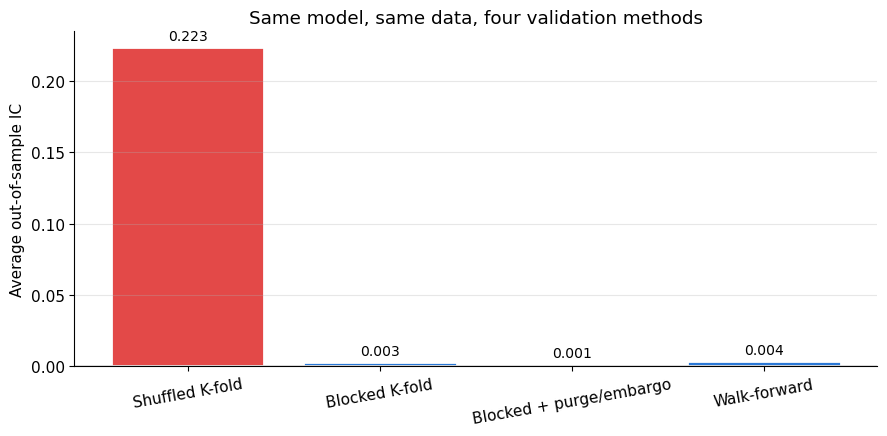

In [4]:
fig, ax = plt.subplots()
names = list(results)
ax.bar(names, [np.mean(results[n]) for n in names],
       color=[COLORS[7]] + [COLORS[0]] * 3, edgecolor="white", linewidth=2)
for i, n in enumerate(names):
    ax.text(i, np.mean(results[n]) + 0.005, f"{np.mean(results[n]):.3f}", ha="center", fontsize=10)
ax.axhline(0, color="grey", linewidth=1)
ax.set_ylabel("Average out-of-sample IC")
ax.set_title("Same model, same data, four validation methods")
ax.tick_params(axis="x", rotation=10)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

The shuffled K-fold reports an average IC of **0.22**, consistently across all five folds, the kind of number that would make headlines. Every method that respects time reports about **0.00**. The model has no real predictive power on this data. The 0.22 is pure leakage: with random folds, almost every test day has its neighbours in the training set, with nearly identical features and nearly identical labels, and the model just looks them up.

Purging made little difference here (0.003 → 0.001). With only five large blocks, just the few days at each block boundary overlap. With more folds, longer label horizons or smaller datasets, the boundary leak becomes much larger. The main lesson is the first bar: **shuffling was responsible for the entire apparent result.**

### 4.4 Walk-forward, year by year

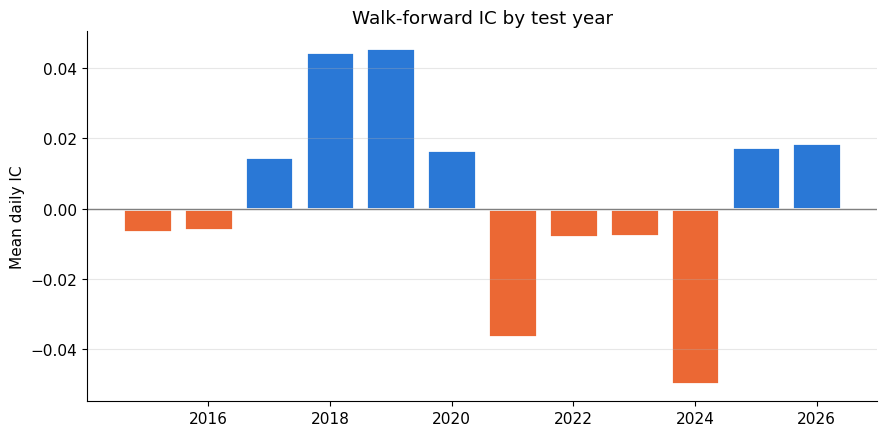

Positive in 6 of 12 years


In [5]:
wf = pd.Series(results["Walk-forward"], index=range(2015, 2015 + len(results["Walk-forward"])))
fig, ax = plt.subplots()
ax.bar(wf.index, wf.values, color=[COLORS[0] if v > 0 else COLORS[1] for v in wf.values],
       edgecolor="white", linewidth=2)
ax.axhline(0, color="grey", linewidth=1)
ax.set_ylabel("Mean daily IC")
ax.set_title("Walk-forward IC by test year")
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()
print(f"Positive in {(wf > 0).sum()} of {len(wf)} years")

The honest picture: half the years positive and half negative, with ICs between about −0.05 and +0.05. This is what a model with no stable edge looks like. It is consistent with S5, where no individual feature was significant. A gradient-boosting model cannot find signal that isn't in the features. It can only find complicated ways to overfit noise, and only an honest validation reveals that.

## 5. Takeaways and where it breaks

- **Never shuffle time-series data for validation.** It lets overlapping labels and slow-moving features leak the answer.
- **Purge and embargo** whenever labels span several periods. The effect grows with the number of folds and the label horizon.
- **Walk-forward is the gold standard** for a final estimate, because it reproduces what you could have done in real time. Blocked, purged K-fold uses more data and is useful for tuning.
- **An IC above about 0.1 on daily stock data should make you suspicious**, not excited. Check the validation first.
- **Where it breaks:** even perfect validation can't fix survivorship bias in the universe (notebook 6), and repeatedly re-running walk-forward tests while tweaking the model slowly turns the test years into training data.

**What you could build:** a validation module for the club, with `purged_kfold(dates, horizon)` and `walk_forward(dates, horizon, step)` splitters that plug into scikit-learn, so every team's ML result is validated the same, honest way.